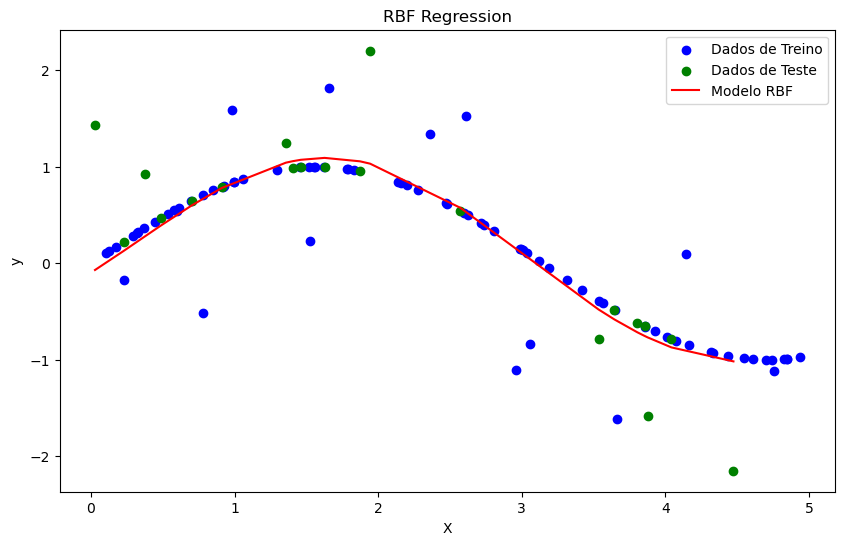

In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np


def resolve_data_path(filename: str, must_exist: bool = True) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    if must_exist:
        raise FileNotFoundError(
            f"Nao foi possivel localizar o arquivo de dados '{filename}' em {candidates}."
        )

    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    return candidates[0].resolve()


# Carregar os dados do arquivo CSV
dados = pd.read_csv(resolve_data_path("7.0 - dados_rbf_regression.csv"))

# Separar os dados em variaveis independentes e dependentes
X = dados[['X']].values
y = dados['y'].values

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar um modelo SVR com kernel RBF
model_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
model_rbf.fit(X_train, y_train)

# Realizar previsoes com o modelo
y_pred = model_rbf.predict(X_test)

# Visualizacao dos resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Dados de Treino')
plt.scatter(X_test, y_test, color='green', label='Dados de Teste')
order = np.argsort(X_test[:, 0])
plt.plot(X_test[order], y_pred[order], color='red', label='Modelo RBF')
plt.title('RBF Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()